In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
%matplotlib inline
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
import scipy.stats as stats
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from numpy.linalg import inv
import scipy.stats as stats
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import networkx as nx

In [ ]:

# reading the qc file
qc_data = pd.read_excel(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\QC_msmetrix.xlsx",
    sheet_name=0,
    header=12
)

print(qc_data.head())

In [37]:
qc_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589 entries, 0 to 588
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Peak                   589 non-null    int64  
 1   tR1                    589 non-null    float64
 2   tR2                    589 non-null    float64
 3   tR                     589 non-null    float64
 4   m/z                    589 non-null    int64  
 5   ID Names               589 non-null    object 
 6   s1 S96_QC1_B1_D1_T1    589 non-null    int64  
 7   s2 S96_QC2_B1_D1_T1    589 non-null    int64  
 8   s3 S96_QC3_B1_D1_T1    589 non-null    int64  
 9   s4 S96_QC4_B1_D1_T1    589 non-null    int64  
 10  s5 S96_QC1_B1_D2_T1    589 non-null    int64  
 11  s6 S96_QC2_B1_D2_T1    589 non-null    int64  
 12  s7 S96_QC3_B1_D2_T1    589 non-null    int64  
 13  s8 S96_QC4_B1_D2_T1    589 non-null    int64  
 14  s9 S96_QC1_B1_D3_T1    589 non-null    int64  
 15  s10 S9

In [38]:

input_path  = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\samples day1-10.xlsx"
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\all_real_samples_combined.xlsx"

# Reading without headers, just to find the header row
df_raw = pd.read_excel(input_path, header=None)

# getting the data columns
header_row = df_raw[df_raw.iloc[:,0].astype(str).str.strip() == "Peak"].index[0]

# Re-reading using that row as the header
potato_data = pd.read_excel(input_path, header=header_row)

# Dropping any completely empty columns
data = potato_data.dropna(axis=1, how="all")

#  Seeing the dataframe
print(data.shape)
print(data.columns.tolist())
print(data.head())

(633, 175)
['Peak', 'tR1', 'tR2', 'tR', 'm/z', 'ID Names', 's1 S96_44_B1_D1_T1', 's1 S96_44_B1_D1_T2', 's3 S96_9_B1_D1_T1', 's4 S96_28_B1_D1_T1', 's5 S96_92_B1_D1_T1', 's6 S96_21_B1_D1_T1', 's7 S96_53_B1_D1_T1', 's8 S96_55_B1_D1_T1', 's9 S96_44_B1_D1_T2', 's10 S96_55_B1_D1_T2', 's11 S96_21_B1_D1_T2', 's12 S96_14_B1_D1_T2', 's13 S96_7_B1_D1_T2', 's14 S96_83_B1_D1_T2', 's15 S96_92_B1_D1_T2', 's16 S96_28_B1_D1_T2', 's17 S96_83_B1_D1_T1', 's18 S96_7_B1_D1_T1', 's19 S96_53_B1_D1_T2', 's20 S96_42_B1_D2_T1', 's21 S96_56_B1_D2_T1', 's22 S96_6_B1_D2_T1', 's23 S96_38_B1_D2_T1', 's24 S96_48_B1_D2_T1', 's25 S96_76_B1_D2_T1', 's26 S96_10_B1_D2_T1', 's27 S96_38_B1_D2_T2', 's28 S96_76_B1_D2_T2', 's29 S96_48_B1_D2_T2', 's30 S96_6_B1_D2_T2', 's31 S96_10_B1_D2_T2', 's32 S96_42_B1_D2_T2', 's33 S96_79_B1_D2_T2', 's34 S96_86_B1_D2_T2', 's35 S96_56_B1_D2_T2', 's36 S96_79_B1_D2_T1', 's37 S96_86_B1_D2_T1', 's38 S96_87_B1_D3_T1', 's39 S96_16_B1_D3_T1', 's40 S96_81_B1_D3_T1', 's41 S96_81_B1_D3_T2', 's42 S96_50_

In [39]:
selected_data = data.iloc[:, :101]

In [40]:
selected_data.isnull().sum()

Peak                   0
tR1                    0
tR2                    0
tR                     0
m/z                    0
                      ..
s91 S96_12_B1_D5_T2    0
s92 S96_93_B1_D5_T2    0
s93 S96_15_B1_D6_T1    0
s94 S96_59_B1_D6_T1    0
s95 S96_25_B1_D6_T1    0
Length: 101, dtype: int64

In [41]:

# the pairwise differences to find the realation between retention times
diff_t_vs_1 = (selected_data['tR'] - selected_data['tR1']).abs()
diff_t_vs_2 = (selected_data['tR'] - selected_data['tR2']).abs()
diff_1_vs_2 = (selected_data['tR1'] - selected_data['tR2']).abs()
avg_t   = (selected_data['tR1'] + selected_data['tR2']) / 2
diff_avg_vs_t = (avg_t - selected_data['tR']).abs()

# printing to see the results
print("abs(tR - tR1):\n", diff_t_vs_1.describe(), "\n")
print("abs(tR - tR2):\n", diff_t_vs_2.describe(), "\n")
print("abs(tR1 - tR2):\n", diff_1_vs_2.describe(), "\n")
print("abs(avg(tR1,tR2) - tR):\n", diff_avg_vs_t.describe(), "\n")


abs(tR - tR1):
 count    633.000000
mean       0.050104
std        0.035097
min        0.015000
25%        0.028000
50%        0.041000
75%        0.061000
max        0.369000
dtype: float64 

abs(tR - tR2):
 count    633.000000
mean       0.050137
std        0.035105
min        0.015000
25%        0.027000
50%        0.041000
75%        0.061000
max        0.369000
dtype: float64 

abs(tR1 - tR2):
 count    633.000000
mean       0.100242
std        0.070199
min        0.030000
25%        0.055000
50%        0.081000
75%        0.122000
max        0.738000
dtype: float64 

abs(avg(tR1,tR2) - tR):
 count    6.330000e+02
mean     2.330174e-04
std      2.496198e-04
min      0.000000e+00
25%      0.000000e+00
50%      3.552714e-15
75%      5.000000e-04
max      5.000000e-04
dtype: float64 



In [44]:

# Compute the pairwise differences 
diff_t_vs_1 = (qc_data['tR'] - qc_data['tR1']).abs()
diff_t_vs_2 = (qc_data['tR'] - qc_data['tR2']).abs()
diff_1_vs_2 = (qc_data['tR1'] - qc_data['tR2']).abs()
avg_t   = (qc_data['tR1'] + qc_data['tR2']) / 2
diff_avg_vs_t = (avg_t - qc_data['tR']).abs()

# Summarize
print("abs(tR - tR1):\n", diff_t_vs_1.describe(), "\n")
print("abs(tR - tR2):\n", diff_t_vs_2.describe(), "\n")
print("abs(tR1 - tR2):\n", diff_1_vs_2.describe(), "\n")
print("abs(avg(tR1,tR2) - tR):\n", diff_avg_vs_t.describe(), "\n")


abs(tR - tR1):
 count    589.000000
mean       0.033163
std        0.018089
min        0.015000
25%        0.021000
50%        0.027000
75%        0.039000
max        0.141000
dtype: float64 

abs(tR - tR2):
 count    589.000000
mean       0.033136
std        0.018078
min        0.015000
25%        0.021000
50%        0.027000
75%        0.038000
max        0.141000
dtype: float64 

abs(tR1 - tR2):
 count    589.000000
mean       0.066299
std        0.036161
min        0.030000
25%        0.042000
50%        0.053000
75%        0.077000
max        0.282000
dtype: float64 

abs(avg(tR1,tR2) - tR):
 count    5.890000e+02
mean     2.393888e-04
std      2.499870e-04
min      0.000000e+00
25%      0.000000e+00
50%      3.552714e-15
75%      5.000000e-04
max      5.000000e-04
dtype: float64 




the two measurements are consistent with each other, and tR serves as a reliable midpoint that smooths out the small differences between them.


In [45]:
# put tr_best instead of other tr
qc_data['tR_best'] = (qc_data['tR1'] + qc_data['tR2']) / 2

# removing unnecessary columns
to_keep = [col for col in qc_data.columns if col not in ['tR1', 'tR2', 'tR']]
cleaned_qc = qc_data[to_keep]

# Confirm that 'tR_best' is included
print("tR_best column saved:", 'tR_best' in cleaned_qc.columns)

cols = cleaned_qc.columns.tolist()

# Moving 'tR_best' after 'Peak'
cols.insert(cols.index('Peak') + 1, cols.pop(cols.index('tR_best')))

# Reorder the DataFrame
cleaned_qc = cleaned_qc[cols]

# Check the result
print(cleaned_qc.head())
# Save cleaned data with tR_best
cleaned_qc.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\cleaned_qc.csv", index=False)
# now this cleaned_qc datafram can be used for further analysis

tR_best column saved: True
   Peak  tR_best  m/z                                           ID Names  \
0     1   1.9065   40    0.15%  || 40                                ...   
1     2   1.9480   44    1.81%  || 44                                ...   
2     3   1.9640   81    0.14%  || 81   69  169  119                 ...   
3     4   1.9895   64    0.80%  || 64   48   61   66   96   37  131  ...   
4     5   2.0250   42    0.82%  || 42  41  40  39  38  50            ...   

   s1 S96_QC1_B1_D1_T1  s2 S96_QC2_B1_D1_T1  s3 S96_QC3_B1_D1_T1  \
0                44728                46928                46096   
1               354392               461936               609704   
2                75703                27041                69053   
3               238856               296333               363394   
4               207592               197912               201184   

   s4 S96_QC4_B1_D1_T1  s5 S96_QC1_B1_D2_T1  s6 S96_QC2_B1_D2_T1  ...  \
0                44488            

# Peak detection for for qc data(compound identification)

In [46]:
# Define known alkanes with accurate retention time (tR) as we know these retention times
alkanes = [
    {'Compound': 'Octane',      'tR': 5.34},
    {'Compound': 'Decane',      'tR': 10.154},
    {'Compound': 'Dodecane',    'tR': 13.626},
    {'Compound': 'Tetradecane', 'tR': 16.388},
    {'Compound': 'Pentadecane', 'tR': 17.62},
    {'Compound': 'Octadecane',  'tR': 20.906},
    {'Compound': 'Eicosane',    'tR': 22.825},
]

# Convert to DataFrame
alkane_df = pd.DataFrame(alkanes)

# Set tighter tolerance for GC-MS matching
tr_tol = 0.2  # try 0.2 min window
mz_tol = 2    # use ±2 m/z

# Matching function
def match_alkane(row):
    for _, alk in alkane_df.iterrows():
        if abs(row['tR_best'] - alk['tR']) <= tr_tol:
            return alk['Compound']
    return 'Unknown'

# Apply cleaned qc
cleaned_qc['Matched_Compound'] = cleaned_qc.apply(match_alkane, axis=1)

# Show matches
matched = cleaned_qc[cleaned_qc['Matched_Compound'] != 'Unknown']
display(matched[['Peak', 'tR_best', 'm/z', 'Matched_Compound']])


,Peak,tR_best,m/z,Matched_Compound
67,68,5.1565,133,Octane
68,69,5.1760,149,Octane
69,70,5.3015,85,Octane
70,71,5.3270,43,Octane
71,72,5.4685,97,Octane
...,...,...,...,...
571,572,22.9020,85,Eicosane
572,573,22.9315,208,Eicosane
573,574,22.9695,57,Eicosane
574,575,22.9960,73,Eicosane


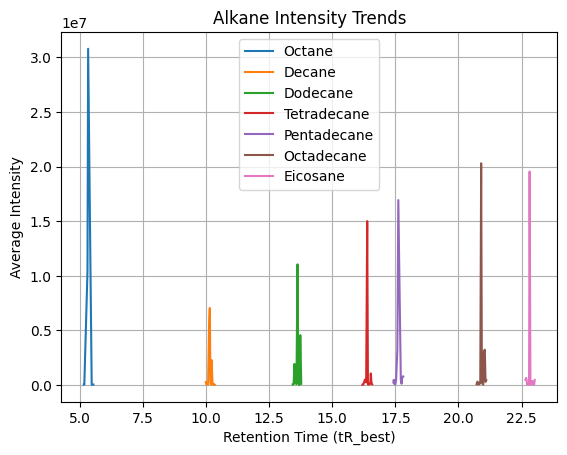

In [47]:
# Select only numeric intensity columns
intensity_cols = cleaned_qc.select_dtypes(include='number').columns.difference(['Peak', 'tR_best', 'm/z'])

# Plot mean intensity for each matched compound
for compound in cleaned_qc['Matched_Compound'].unique():
    if compound != 'Unknown':
        subset = cleaned_qc[cleaned_qc['Matched_Compound'] == compound]
        avg_intensity = subset[intensity_cols].mean(axis=1)
        plt.plot(subset['tR_best'], avg_intensity, label=compound)

plt.xlabel('Retention Time (tR_best)')
plt.ylabel('Average Intensity')
plt.title('Alkane Intensity Trends')
plt.legend()
plt.grid(True)
plt.show() 

# QC-Based Drift Correction Model (m/z = 57)

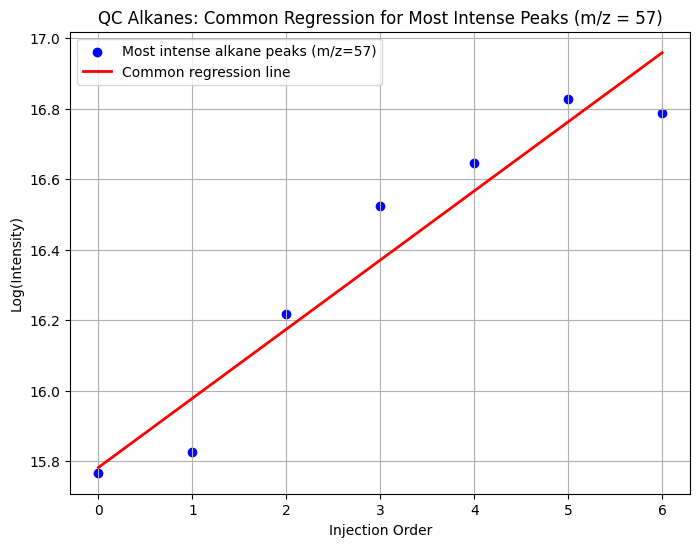

Common Regression Slope: 0.1961
Intercept: 15.7823


In [48]:

alpha = 0.05        # p-value threshold for drift significance
frac = 0.2          # LOESS smoothing parameter

# Identify intensity columns 
intensity_cols = cleaned_qc.select_dtypes(include='number').columns.difference(['Peak', 'tR_best', 'm/z'])

# Transpose , rows = injections, columns = compounds
alkane_matrix = cleaned_qc[['Matched_Compound'] + list(intensity_cols)]
alkane_matrix = alkane_matrix.set_index('Matched_Compound').T
alkane_matrix = alkane_matrix.reset_index().rename(columns={'index': 'Filename'})

# Merge with injection metadata 
merged = master_table.merge(alkane_matrix, on='Filename', how='inner')
merged = merged.sort_values(by='True_Injection_Order').reset_index(drop=True)
corrected = merged.copy()

# Loop through each compound and perform LOESS drift correction 
results = []
compounds = cleaned_qc['Matched_Compound'].unique()

for compound in compounds:
    y = merged[compound].values
    X = sm.add_constant(merged['True_Injection_Order'].values)
    model = sm.OLS(y, X).fit()
    slope, pvalue = model.params[1], model.pvalues[1]
    
    if pvalue < alpha:  # Significant drift
        loess_fit = lowess(y, merged['True_Injection_Order'], frac=frac, return_sorted=False)
        corrected[compound] = y - (loess_fit - loess_fit[0])  # normalize to first injection
        corrected_flag = True
    else:
        corrected_flag = False  # No correction applied
    
    results.append({
        'Compound': compound,
        'Slope': slope,
        'p-value': pvalue,
        'Corrected': corrected_flag
    })

# Create drift summary 
drift_summary = pd.DataFrame(results).sort_values('p-value')

#  Outputs 
print("Drift correction complete.")
print(drift_summary.head())   
corrected.head()               


If p-value < 0.05 → The drift is statistically significant, and it must be corrected.

If p-value > 0.05 → The drift is weak (not statistically significant), and it can be ignored.

Next steps after this:

We can apply drift correction only to the compounds where the drift is significant.

Optionally, we can use non-linear methods (e.g., LOESS smoothing) if the drift is not linear.

# QC preparation

In [ ]:


# Separate metadata and features
metadata_cols = ['Filename', 'True_Injection_Order']
intensities = corrected_data.drop(columns=metadata_cols).copy()

#  QC-based feature filtering
qc_mask = corrected_data['Filename'].str.contains("QC", case=False, na=False)
qc_data = intensities[qc_mask]
rsd = qc_data.std(axis=0) / qc_data.mean(axis=0)
kept_features = rsd[rsd < 0.3].index
intensities = intensities[kept_features]

print(f"Features kept after RSD filtering: {len(kept_features)}")

# Probabilistic Quotient Normalization (PQN) 
qc_median = qc_data[kept_features].median(axis=0)
quotients = intensities.div(qc_median, axis=1)
pqn_factors = quotients.median(axis=1)
intensities = intensities.div(pqn_factors, axis=0)

# Log transform 
intensities = np.log1p(intensities)

#  KNN Imputation 
imputer = KNNImputer(n_neighbors=3)
intensities_imputed = imputer.fit_transform(intensities)
intensities = pd.DataFrame(intensities_imputed, columns=kept_features, index=corrected_data.index)

# Autoscaling (z-score) 
scaler = StandardScaler()
intensities_scaled = scaler.fit_transform(intensities)
processed_features = pd.DataFrame(intensities_scaled, columns=kept_features, index=corrected_data.index)

#  Add metadata back 
processed_data = pd.concat([corrected_data[metadata_cols], processed_features], axis=1)

print(f"Final processed data shape: {processed_data.shape}")


# Check QC performance



In [ ]:

# Separate metadata and features 
metadata_cols = ['Filename', 'True_Injection_Order']
features = prepared_qc_data.drop(columns=metadata_cols)

# Identify QCs 
qc_mask = prepared_qc_data['Filename'].str.contains("QC", case=False, na=False)

#  PCA on all features 
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(features)

#  Plot PCA (QCs vs Samples) 
plt.figure(figsize=(8,6))
plt.scatter(pca_scores[~qc_mask,0], pca_scores[~qc_mask,1], alpha=0.5, color='blue', label='Samples')
plt.scatter(pca_scores[qc_mask,0], pca_scores[qc_mask,1], color='red', label='QCs')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA: QC vs Samples")
plt.legend()
plt.grid(True)
plt.show()

# RSD (Relative Standard Deviation) for QC features 
qc_data = features[qc_mask]
rsd = qc_data.std(axis=0) / qc_data.mean(axis=0)

#  Plot RSD distribution 
plt.figure(figsize=(8,6))
plt.hist(rsd, bins=30, color='green', alpha=0.7)
plt.axvline(0.3, color='red', linestyle='--', label='RSD = 0.3 threshold')
plt.xlabel("Relative Standard Deviation (RSD)")
plt.ylabel("Number of features")
plt.title("RSD distribution of QC features")
plt.legend()
plt.grid(True)
plt.show()

#  Print RSD statistics 
print(f"Median RSD of retained features: {rsd.median():.3f}")
print(f"Features with RSD > 0.3: {(rsd > 0.3).sum()} (should be 0 if filtered properly)")


# flag/remove outlier and re‑process

# Sample prepration

In [ ]:
#  Select metadata and retained features 
metadata_cols = ['Filename', 'True_Injection_Order']
intensities = corrected_data[retained_features].copy()

# Probabilistic Quotient Normalization (PQN) using QC reference 
quotients = intensities.div(qc_reference, axis=1)
pqn_factors = quotients.median(axis=1)
intensities = intensities.div(pqn_factors, axis=0)

# Log transform 
intensities = np.log1p(intensities)

# KNN Imputation for missing values 
imputer = KNNImputer(n_neighbors=3)
intensities_imputed = imputer.fit_transform(intensities)
intensities = pd.DataFrame(intensities_imputed, columns=retained_features, index=corrected_data.index)

# Autoscaling (z-score) 
scaler = StandardScaler()
intensities_scaled = scaler.fit_transform(intensities)
processed_features = pd.DataFrame(intensities_scaled, columns=retained_features, index=corrected_data.index)

# Add metadata back 
processed_samples = pd.concat([corrected_data[metadata_cols], processed_features], axis=1)

# Output 
print(f"Processed samples shape: {processed_samples.shape}")
processed_samples.head()


# Feature importance & discrimination

In [ ]:
# Reshape & extract metadata

processed_samples

# Load data
df =processed_samples.copy()
# Take only intensity columns
intensity_cols = [c for c in df.columns if c.startswith('s')]
feature_data = df[intensity_cols].T
feature_data.columns = df['peak']  # Set feature names

# Extract SampleID (genotype/treatment)
metadata = feature_data.index.str.extract(r"S96_(\d+)_B\d+_D\d+_T\d+")
metadata.columns = ['SampleID']
metadata.index = feature_data.index
metadata['SampleID'] = metadata['SampleID'].astype(int)

groups = metadata['SampleID']  # group by SampleID



# Anova by sample id

In [ ]:
from scipy.stats import f_oneway
from statsmodels.stats.multitest import multipletests

p_values = []
for feature in feature_data.columns:
    data_by_group = [feature_data[groups == g][feature] for g in groups.unique()]
    stat, p = f_oneway(*data_by_group)
    p_values.append(p)

# Adjust p-values (FDR)
adjusted_p = multipletests(p_values, alpha=0.05, method='fdr_bh')[1]
anova_results = pd.DataFrame({'Feature': feature_data.columns, 'p-value': p_values, 'FDR': adjusted_p})
significant = anova_results[anova_results['FDR'] < 0.05].sort_values('FDR')

print("Top significant metabolites by SampleID:")
print(significant.head(20))


we can use this subset of peaks for:

PLS‑DA

Clustering (heatmaps)

Correlation networks

Merging with genetic data (for GWAS)

Biological interpretation (KEGG, MetaboAnalyst).

# PLS‑DA

In [ ]:


# Prepare Y (one-hot encoded SampleID)
Y = OneHotEncoder(sparse=False).fit_transform(groups.values.reshape(-1,1))

# Fit PLS-DA
pls = PLSRegression(n_components=2)
pls.fit(feature_data, Y)
scores = pls.transform(feature_data)

# Plot PLS-DA scores
plt.figure(figsize=(8,6))
for sample_id in np.unique(groups):
    idx = groups == sample_id
    plt.scatter(scores[idx,0], scores[idx,1], label=f"ID {sample_id}")
plt.xlabel("PLS-DA Component 1")
plt.ylabel("PLS-DA Component 2")
plt.title("PLS-DA: Separation by SampleID")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def calculate_vip(pls, X):
    t = pls.x_scores_
    w = pls.x_weights_
    q = pls.y_loadings_
    p, h = w.shape
    s = np.diag(t.T @ t @ q.T @ q).reshape(h, -1)
    total_s = np.sum(s)
    vip = np.sqrt(p * (w**2 @ s) / total_s).ravel()
    return vip

vip_scores = calculate_vip(pls, feature_data)
vip_series = pd.Series(vip_scores, index=feature_data.columns).sort_values(ascending=False)
print(vip_series.head(20))  # Top discriminating metabolites


# Hierarchical Clustering Heatmap (Top VIP compounds)

In [ ]:

# Select top 20 VIP compounds
top_features = vip_series.head(20).index
subset = feature_data[top_features]

# Create clustered heatmap
sns.clustermap(subset, method='ward', cmap='vlag', figsize=(12,8), 
               row_cluster=True, col_cluster=True,
               xticklabels=False, yticklabels=top_features)
plt.title("Hierarchical Clustering of Top VIP Compounds")
plt.show()


# Metabolite Relationships

In [ ]:


# Correlation matrix for top VIP features
corr = subset.corr()

# Create edges for |r| > 0.7
edges = [(i, j, corr.loc[i,j]) for i in corr.columns for j in corr.columns 
         if abs(corr.loc[i,j]) > 0.7 and i != j]

# Build network
G = nx.Graph()
for i,j,w in edges:
    G.add_edge(i, j, weight=w)

# Draw network
plt.figure(figsize=(10,8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=800, font_size=8,
        node_color='skyblue', edge_color='gray')
plt.title("Correlation Network of Top VIP Compounds (|r| > 0.7)")
plt.show()
